# Notebook 04 -- Feature Engineering & Master Panel (v2)

## Macro-Aviation-Tourism Demand Modelling and Forecasting for Poland

**Author:** Diego Marrero Ferrera  
**Repository:** [GitHub -- Macro-Aviation-Tourism-Modeling](https://github.com/DieGodMF4/Macro-Aviation-Tourism-Modeling)  
**Last updated:** 2026-04

---

### Purpose

This notebook transforms the raw Eurostat and ONS datasets into the `master_panel_monthly.csv` that will be consumed by all modelling notebooks (05-08). It is the bridge between the exploratory/statistical phase and the modelling phase.

**This is version 2**, incorporating feedback from the thesis supervisor:

1. **UK data integration via chain-linking with ONS primary sources** (HICP D7BT, GDP ABMI, Population UKPOP) instead of extrapolating the Eurostat series. The UK accounts for 18.8% of air passenger weight and its values during 2020-2025 cannot be reliably extrapolated from pre-pandemic history due to the post-2022 inflation shock.
2. **COVID dummies reconfigured:** `covid_strong` (2020-2021, hard pandemic period) and `covid_post` (2022-2025, post-pandemic adjustment capturing the level shift).
3. **GDP per capita and population added** as separate features alongside real GDP. The three variables are not mathematically redundant in terms of information content: GDP per capita captures individual-level wealth, population captures market size, and real GDP captures aggregate demand.
4. **Lag features reduced** to a maximum of 1-2 per variable to avoid model bloat.
5. **VIF analysis** computed on first differences (not levels, since level-based VIF is dominated by shared secular trends).
6. **CCI UK is excluded entirely**; the German CCI serves as the main sentiment indicator.

---

## 0. Environment & Configuration

In [1]:
import pandas as pd
import numpy as np
import os
import re
import warnings

warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.interpolate import CubicSpline
from statsmodels.stats.outliers_influence import variance_inflation_factor

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('notebook', font_scale=1.1)
plt.rcParams.update({
    'figure.figsize': (12, 6), 'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13, 'axes.titleweight': 'bold',
    'axes.labelsize': 11, 'font.size': 10, 'legend.fontsize': 9,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.4, 'grid.linestyle': '--',
    'lines.linewidth': 2.0,
    'savefig.bbox': 'tight', 'savefig.dpi': 200, 'savefig.facecolor': 'white',
})

COLORS = {
    'primary': '#2c3e50', 'secondary': '#e74c3c',
    'accent1': '#3498db', 'accent2': '#2ecc71',
    'accent3': '#f39c12', 'accent4': '#9b59b6', 'gray': '#95a5a6',
}

pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.4f}'.format)

print('Environment ready.')

Environment ready.


In [2]:
# PATHS:
DATA_RAW       = os.path.join('..', 'data', 'raw')
DATA_PROCESSED = os.path.join('..', 'data', 'processed')
FIGURES        = os.path.join('..', 'figures', 'features')
os.makedirs(DATA_PROCESSED, exist_ok=True)
os.makedirs(FIGURES, exist_ok=True)

FILES = {
    'nights':     os.path.join(DATA_RAW, 'tourism',
                      'tour_occ_nights_accommodation_PL_2003-.csv'),
    'hicp_m':     os.path.join(DATA_RAW, 'economic',
                      'prc_hicp_midx__relevant-countries-2011-.csv'),
    'exr':        os.path.join(DATA_RAW, 'economic',
                      'ert_bil_eur_m__exchange-rates-eur-pln-usd-2003-.csv'),
    'gdp_real':   os.path.join(DATA_RAW, 'economic',
                      'namq_10_gdp__real-gdp-CLV-2010.csv'),
    'cci':        os.path.join(DATA_RAW, 'demographic',
                      'ei_bsco_m__consumer-conf-indicator.csv'),
    'pop_eurostat': os.path.join(DATA_RAW, 'demographic',
                      'demo_pjan__population-eur-990-25.csv'),
    'avia_seats': os.path.join(DATA_RAW, 'transport',
                      'avia_tf_aca__seats-flights-pass-PL-2010-.csv'),
    'avia_pax':   os.path.join(DATA_RAW, 'transport',
                      'avia_paoc__passengers-countries.csv'),
    # UK-specific from ONS
    'hicp_uk':    os.path.join(DATA_RAW, 'uk_specific',
                      'ons_hicp_uk_d7bt.csv'),
    'gdp_uk':     os.path.join(DATA_RAW, 'uk_specific',
                      'ons_gdp_uk_abmi.csv'),
    'pop_uk':     os.path.join(DATA_RAW, 'uk_specific',
                      'ons_pop_uk.csv'),
}

NAME_TO_CODE = {
    'Austria': 'AT', 'Croatia': 'HR', 'Czechia': 'CZ',
    'France': 'FR', 'Germany': 'DE', 'Greece': 'EL',
    'Hungary': 'HU', 'Italy': 'IT', 'Netherlands': 'NL',
    'Poland': 'PL', 'Spain': 'ES', 'Sweden': 'SE',
    'United Kingdom': 'UK', 'United States': 'US',
}
CURRENCY_MAP = {
    'Polish zloty': 'PLN', 'Pound sterling': 'GBP',
    'Swedish krona': 'SEK', 'Czech koruna': 'CZK',
    'Hungarian forint': 'HUF', 'US dollar': 'USD',
}
NON_EURO = {'UK': 'GBP', 'SE': 'SEK', 'CZ': 'CZK', 'HU': 'HUF'}
ORIGINS = ['DE', 'UK', 'FR', 'NL', 'IT', 'ES', 'SE', 'AT', 'CZ']


def savefig(name):
    plt.savefig(os.path.join(FIGURES, name))


print('Paths and mappings ready.')

Paths and mappings ready.


## 1. Loader Functions

In [3]:
def load_eurostat(path):
    """Load a standard Eurostat CSV with TIME_PERIOD / geo columns."""
    df = pd.read_csv(path)
    if 'TIME_PERIOD' in df.columns:
        tp = df['TIME_PERIOD'].astype(str)
        if tp.str.match(r'^\d{4}-\d{2}$').all():
            df['date'] = pd.to_datetime(tp, format='%Y-%m')
        elif tp.str.match(r'^\d{4}-Q\d$').all():
            df['date'] = pd.PeriodIndex(tp, freq='Q').to_timestamp()
        elif tp.str.match(r'^\d{4}$').all():
            df['date'] = pd.to_datetime(tp, format='%Y')
        else:
            df['date'] = pd.to_datetime(tp, errors='coerce')
    if 'geo' in df.columns:
        df['iso'] = df['geo'].map(NAME_TO_CODE)
    return df


def load_eurostat_pop(path):
    """
    Load the demo_pjan population file which uses a non-standard SDMX
    flat format without header row.
    Columns (no header): dataflow, last_update, freq, unit, sex, age,
    geo, TIME_PERIOD, OBS_VALUE, OBS_FLAG, CONF_STATUS
    """
    df = pd.read_csv(path, header=None, names=[
        'dataflow', 'last_update', 'freq', 'unit', 'sex', 'age',
        'geo', 'TIME_PERIOD', 'OBS_VALUE', 'OBS_FLAG', 'CONF_STATUS'
    ])
    df = df[(df['sex'] == 'Total') & (df['age'] == 'Total')]
    df['date'] = pd.to_datetime(df['TIME_PERIOD'].astype(str), format='%Y')
    df['iso'] = df['geo'].map(NAME_TO_CODE)
    df['OBS_VALUE'] = pd.to_numeric(df['OBS_VALUE'], errors='coerce')
    return df.dropna(subset=['iso', 'OBS_VALUE'])


def load_ons(path, frequency='monthly'):
    """
    Load an ONS time series CSV.
    ONS files mix annual, quarterly and monthly rows in one file.
    Date formats: 'YYYY' (annual), 'YYYY Q#' (quarterly), 'YYYY MMM' (monthly).
    """
    df = pd.read_csv(path, header=None, names=['date_str', 'value'],
                     skiprows=8, dtype={'date_str': str, 'value': str})
    df = df.dropna(subset=['date_str', 'value'])
    df['value'] = pd.to_numeric(df['value'], errors='coerce')
    df = df.dropna(subset=['value'])

    pat_annual    = re.compile(r'^\d{4}$')
    pat_quarterly = re.compile(r'^\d{4}\s*Q[1-4]$')
    pat_monthly   = re.compile(r'^\d{4}\s+[A-Z]{3}$')

    if frequency == 'annual':
        mask = df['date_str'].str.match(pat_annual)
        sub = df[mask].copy()
        sub['date'] = pd.to_datetime(sub['date_str'], format='%Y')
    elif frequency == 'quarterly':
        mask = df['date_str'].str.match(pat_quarterly)
        sub = df[mask].copy()
        sub['date'] = pd.PeriodIndex(
            sub['date_str'].str.replace(' ', ''), freq='Q'
        ).to_timestamp()
    elif frequency == 'monthly':
        mask = df['date_str'].str.match(pat_monthly)
        sub = df[mask].copy()
        sub['date'] = pd.to_datetime(sub['date_str'], format='%Y %b')
    else:
        raise ValueError(f'Unknown frequency: {frequency}')

    return sub.set_index('date')['value'].sort_index()


def cubic_spline_interpolate(series):
    """Cubic spline from lower to monthly frequency."""
    s = series.dropna()
    if len(s) < 4:
        return pd.Series(dtype=float)
    x = (s.index - s.index[0]).days.values.astype(float)
    y = s.values.astype(float)
    cs = CubicSpline(x, y, bc_type='natural')
    m_idx = pd.date_range(s.index[0], s.index[-1], freq='MS')
    x_m = (m_idx - s.index[0]).days.values.astype(float)
    return pd.Series(cs(x_m), index=m_idx, name=s.name)


print('Loaders defined.')

Loaders defined.


## 2. Load Raw Datasets

In [4]:
# Target:
df_raw = load_eurostat(FILES['nights'])
ACCOM_TOTAL = ('Hotels; holiday and other short-stay accommodation; '
               'camping grounds, recreational vehicle parks and trailer parks')
mask = (
    (df_raw['geo'] == 'Poland') &
    (df_raw['c_resid'] == 'Foreign country') &
    (df_raw['unit'] == 'Number') &
    (df_raw['nace_r2'] == ACCOM_TOTAL)
)
ts_nights = (df_raw.loc[mask].set_index('date')['OBS_VALUE']
                .sort_index().rename('nights'))
ts_nights = ts_nights[ts_nights.index >= '2011-01-01']
print(f'Target: {len(ts_nights)} obs')

# HICP:
df_hicp = load_eurostat(FILES['hicp_m'])
hicp_wide = (df_hicp[df_hicp['iso'].notna()]
             .pivot_table(index='date', columns='iso', values='OBS_VALUE')
             .sort_index())
print(f'HICP: {hicp_wide.shape}')

# Exchange rates:
df_exr = load_eurostat(FILES['exr'])
df_exr['curr_iso'] = df_exr['currency'].map(CURRENCY_MAP)
exr_wide = (df_exr[df_exr['curr_iso'].notna()]
            .pivot_table(index='date', columns='curr_iso', values='OBS_VALUE')
            .sort_index())
print(f'Exchange rates: {exr_wide.shape}')

# GDP (quarterly):
df_gdp = load_eurostat(FILES['gdp_real'])
gdp_quarterly = (df_gdp[df_gdp['iso'].notna()]
                 .pivot_table(index='date', columns='iso', values='OBS_VALUE')
                 .sort_index())
print(f'GDP quarterly: {gdp_quarterly.shape}')

# CCI:
df_cci = load_eurostat(FILES['cci'])
cci_wide = (df_cci[df_cci['iso'].notna()]
            .pivot_table(index='date', columns='iso', values='OBS_VALUE')
            .sort_index())
print(f'CCI: {cci_wide.shape}')

# Population (Eurostat annual):
df_pop = load_eurostat_pop(FILES['pop_eurostat'])
pop_wide = (df_pop.pivot_table(index='date', columns='iso', values='OBS_VALUE')
            .sort_index())
print(f'Population annual (Eurostat): {pop_wide.shape}')

# Seats:
df_avia = load_eurostat(FILES['avia_seats'])
ts_seats = (df_avia[df_avia['tra_meas'] == 'Passengers seats available']
            .groupby('date')['OBS_VALUE'].sum()
            .sort_index().rename('seats'))
print(f'Seats: {len(ts_seats)} obs')

# Passenger weights for origin averaging:
df_pax = load_eurostat(FILES['avia_pax'])
pax_totals = (df_pax[df_pax['iso'].isin(ORIGINS)]
              .groupby('iso')['OBS_VALUE'].sum())
pax_weights = (pax_totals / pax_totals.sum()).to_dict()
print(f'Passenger weights loaded for {len(pax_weights)} countries')

Target: 179 obs
HICP: (276, 14)
Exchange rates: (278, 6)
GDP quarterly: (124, 12)
CCI: (254, 12)
Population annual (Eurostat): (36, 13)
Seats: 190 obs
Passenger weights loaded for 9 countries


---

## 3. UK Data Integration via Chain-Linking

Post-Brexit, the UK stopped reporting several macroeconomic series to Eurostat: **UK HICP** ends in November 2020 and **UK GDP** ends in Q3 2020. Given that the UK accounts for **18.8% of air passenger weight** to Poland, dropping it would distort the weighted averages across all exogenous variables.

Following tutor consultation, the decision was made to **integrate primary data from the UK Office for National Statistics (ONS)** rather than extrapolating the Eurostat series. This preserves the empirical integrity of the dataset during the most volatile years of recent macroeconomic history (the post-pandemic inflation shock of 2022-2023 could not have been reasonably extrapolated from pre-2020 data).

The integration uses **chain-linking**, a standard technique in international macroeconomics for splicing series from different statistical sources:

1. Identify the last period with data in both Eurostat and ONS series.
2. Compute the ratio `factor = value_eurostat / value_ons` at that overlap.
3. Multiply all post-gap ONS observations by this factor, rescaling them to the Eurostat base. Both currency differences (GBP vs EUR) and base year differences (CLV2022 vs CLV2010) are absorbed automatically.
4. Concatenate the rescaled ONS series with the original Eurostat series.

**Sources used:**
- UK HICP: ONS series D7BT (Consumer Prices Index, all items, base 2015=100, monthly).
- UK GDP: ONS series ABMI (Gross Domestic Product: chained volume measures, seasonally adjusted, quarterly).
- UK Population: ONS UKPOP (mid-year estimates, annual).

**CCI UK is excluded entirely**: the UK has never been part of the Eurostat BCS system, and the weighted-average CCI across origins was shown in Notebook 02 to be a weak predictor anyway (r≈0.13). The German CCI alone (r≈0.37 in YoY at lag 2) serves as the main sentiment indicator.

### 3.1 HICP UK chain-linking

In [5]:
# Load ONS HICP UK:
ons_hicp_uk = load_ons(FILES['hicp_uk'], frequency='monthly')
print(f'ONS HICP UK: {len(ons_hicp_uk)} months '
      f'({ons_hicp_uk.index.min():%Y-%m} -> {ons_hicp_uk.index.max():%Y-%m})')

# Identify overlap point:
eurostat_uk_hicp = hicp_wide['UK'].dropna()
last_overlap = eurostat_uk_hicp.index[-1]
print(f'Eurostat UK HICP ends at: {last_overlap:%Y-%m}')

# Compute chain-link factor:
if last_overlap in ons_hicp_uk.index:
    factor = eurostat_uk_hicp.iloc[-1] / ons_hicp_uk.loc[last_overlap]
else:
    closest = ons_hicp_uk.index[ons_hicp_uk.index <= last_overlap][-1]
    factor = eurostat_uk_hicp.iloc[-1] / ons_hicp_uk.loc[closest]
    last_overlap = closest

print(f'Chain-link factor at {last_overlap:%Y-%m}: {factor:.6f}')
print(f'  Eurostat value: {eurostat_uk_hicp.iloc[-1]:.2f}')
print(f'  ONS value:      {ons_hicp_uk.loc[last_overlap]:.2f}')

# Rescale and concatenate:
ons_rescaled = ons_hicp_uk.loc[ons_hicp_uk.index > last_overlap] * factor
hicp_wide['UK'] = pd.concat([eurostat_uk_hicp, ons_rescaled]).sort_index()

print(f'\nUK HICP after chain-linking: '
      f'{hicp_wide["UK"].dropna().index.min():%Y-%m} -> '
      f'{hicp_wide["UK"].dropna().index.max():%Y-%m} '
      f'({hicp_wide["UK"].notna().sum()} obs)')

ONS HICP UK: 458 months (1988-01 -> 2026-02)
Eurostat UK HICP ends at: 2020-11
Chain-link factor at 2020-11: 1.000000
  Eurostat value: 108.90
  ONS value:      108.90

UK HICP after chain-linking: 2003-01 -> 2025-12 (276 obs)


### 3.2 GDP UK chain-linking

In [6]:
# Load ONS GDP UK:
ons_gdp_uk = load_ons(FILES['gdp_uk'], frequency='quarterly')
print(f'ONS GDP UK: {len(ons_gdp_uk)} quarters '
      f'({ons_gdp_uk.index.min():%Y-%m} -> {ons_gdp_uk.index.max():%Y-%m})')

eurostat_uk_gdp = gdp_quarterly['UK'].dropna()
last_overlap_q = eurostat_uk_gdp.index[-1]
print(f'Eurostat UK GDP ends at: {last_overlap_q:%Y-%m}')

if last_overlap_q in ons_gdp_uk.index:
    gdp_factor = eurostat_uk_gdp.iloc[-1] / ons_gdp_uk.loc[last_overlap_q]
else:
    closest = ons_gdp_uk.index[ons_gdp_uk.index <= last_overlap_q][-1]
    gdp_factor = eurostat_uk_gdp.iloc[-1] / ons_gdp_uk.loc[closest]
    last_overlap_q = closest

print(f'Chain-link factor at {last_overlap_q:%Y-%m}: {gdp_factor:.6f}')
print(f'  (absorbs GBP->EUR conversion and base year difference)')

ons_gdp_rescaled = ons_gdp_uk.loc[ons_gdp_uk.index > last_overlap_q] * gdp_factor
gdp_quarterly['UK'] = pd.concat([eurostat_uk_gdp, ons_gdp_rescaled]).sort_index()

print(f'\nUK GDP after chain-linking: '
      f'{gdp_quarterly["UK"].dropna().index.min():%Y-%m} -> '
      f'{gdp_quarterly["UK"].dropna().index.max():%Y-%m}')

ONS GDP UK: 284 quarters (1955-01 -> 2025-10)
Eurostat UK GDP ends at: 2020-07
Chain-link factor at 2020-07: 0.825050
  (absorbs GBP->EUR conversion and base year difference)

UK GDP after chain-linking: 1995-01 -> 2025-10


### 3.3 Population UK from ONS

In [7]:
# Load ONS UK population (annual):
ons_pop_uk = load_ons(FILES['pop_uk'], frequency='annual')
print(f'ONS UK Population: {len(ons_pop_uk)} years '
      f'({ons_pop_uk.index.year.min()} -> {ons_pop_uk.index.year.max()})')

# Replace Eurostat UK population (which has gaps) with ONS data
pop_wide['UK'] = ons_pop_uk.reindex(pop_wide.index).combine_first(pop_wide['UK'])

print(f'Population (all countries): {pop_wide.shape}')

ONS UK Population: 55 years (1971 -> 2025)
Population (all countries): (36, 13)


### 3.4 Chain-linking visual check

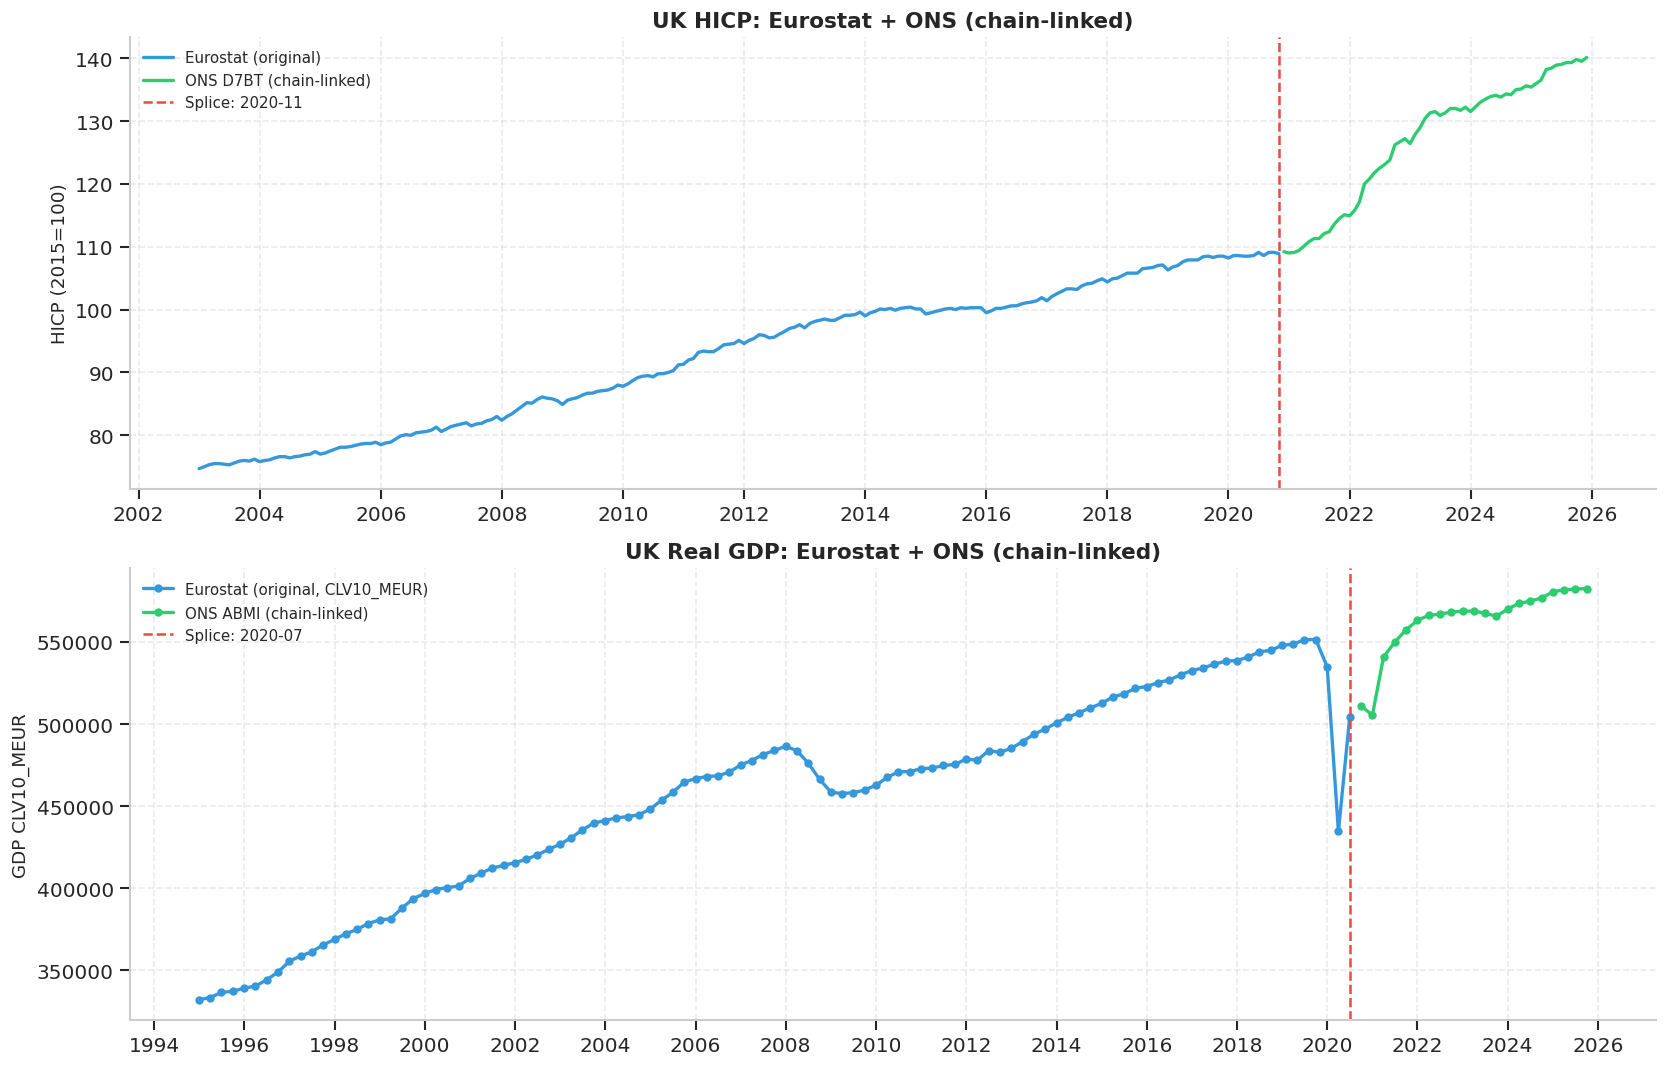

In [8]:
# Visual check: continuity at splice points:
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# HICP
ax = axes[0]
eu_hicp_orig = hicp_wide['UK'].loc[:last_overlap]
ons_portion  = hicp_wide['UK'].loc[last_overlap + pd.DateOffset(months=1):]
ax.plot(eu_hicp_orig.index, eu_hicp_orig.values,
        color=COLORS['accent1'], lw=2, label='Eurostat (original)')
ax.plot(ons_portion.index, ons_portion.values,
        color=COLORS['accent2'], lw=2, label='ONS D7BT (chain-linked)')
ax.axvline(last_overlap, color=COLORS['secondary'],
           ls='--', lw=1.5, label=f'Splice: {last_overlap:%Y-%m}')
ax.set_title('UK HICP: Eurostat + ONS (chain-linked)', fontweight='bold')
ax.set_ylabel('HICP (2015=100)')
ax.legend(loc='upper left')
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# GDP
ax = axes[1]
eu_gdp_orig = gdp_quarterly['UK'].loc[:last_overlap_q]
ons_gdp_portion = gdp_quarterly['UK'].loc[last_overlap_q + pd.DateOffset(months=3):]
ax.plot(eu_gdp_orig.index, eu_gdp_orig.values,
        color=COLORS['accent1'], lw=2, marker='o', ms=4,
        label='Eurostat (original, CLV10_MEUR)')
ax.plot(ons_gdp_portion.index, ons_gdp_portion.values,
        color=COLORS['accent2'], lw=2, marker='o', ms=4,
        label='ONS ABMI (chain-linked)')
ax.axvline(last_overlap_q, color=COLORS['secondary'],
           ls='--', lw=1.5, label=f'Splice: {last_overlap_q:%Y-%m}')
ax.set_title('UK Real GDP: Eurostat + ONS (chain-linked)', fontweight='bold')
ax.set_ylabel('GDP CLV10_MEUR')
ax.legend(loc='upper left')
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
savefig('00_uk_chain_linking.png')
plt.show()

---

## 4. GDP & Population: Cubic Spline Interpolation to Monthly

GDP is quarterly and population is annual. For the monthly panel we interpolate both to monthly frequency using **cubic splines**, which produce a smoother trajectory than linear interpolation while exactly preserving the original observations at the knots (Song et al., 2009).

In [9]:
# GDP quarterly -> monthly:
gdp_monthly = pd.DataFrame()
for iso in gdp_quarterly.columns:
    gdp_monthly[iso] = cubic_spline_interpolate(gdp_quarterly[iso])

print(f'GDP monthly: {gdp_monthly.shape}')
print(f'Period: {gdp_monthly.index.min():%Y-%m} -> {gdp_monthly.index.max():%Y-%m}')

# Population annual -> monthly:
pop_monthly = pd.DataFrame()
for iso in pop_wide.columns:
    pop_monthly[iso] = cubic_spline_interpolate(pop_wide[iso].dropna())

print(f'Population monthly: {pop_monthly.shape}')

GDP monthly: (370, 12)
Period: 1995-01 -> 2025-10
Population monthly: (421, 13)


## 5. Feature Construction

### 5.1 Panel index and target

In [10]:
STUDY_START = '2011-01-01'
STUDY_END = ts_nights.index[-1]
panel_idx = pd.date_range(STUDY_START, STUDY_END, freq='MS')
panel = pd.DataFrame(index=panel_idx)
panel.index.name = 'date'

panel['nights'] = ts_nights.reindex(panel_idx)
panel['log_nights'] = np.log1p(panel['nights'])

print(f'Panel: {len(panel_idx)} months '
      f'({panel_idx[0]:%Y-%m} -> {panel_idx[-1]:%Y-%m})')

Panel: 179 months (2011-01 -> 2025-11)


### 5.2 HICP ratio and relative tourism price (Song et al., 2010)

In [11]:
# HICP ratio:
panel['hicp_PL'] = hicp_wide['PL'].reindex(panel_idx)
origin_hicp_cols = [c for c in ORIGINS if c in hicp_wide.columns]
hicp_origins = hicp_wide[origin_hicp_cols].reindex(panel_idx)
w_h = np.array([pax_weights.get(c, 0) for c in origin_hicp_cols])
w_h = w_h / w_h.sum()
panel['hicp_origins_wavg'] = hicp_origins.values @ w_h
panel['hicp_ratio'] = panel['hicp_PL'] / panel['hicp_origins_wavg']

# Exchange rate PLN/EUR:
panel['exr_pln'] = exr_wide['PLN'].reindex(panel_idx)

# Relative tourism price per origin (Song et al. 2010):
relprice = pd.DataFrame(index=panel_idx)
for iso in ORIGINS:
    if iso not in hicp_wide.columns:
        continue
    hicp_i = hicp_wide[iso].reindex(panel_idx)
    hicp_r = panel['hicp_PL'] / hicp_i
    if iso in NON_EURO:
        curr = NON_EURO[iso]
        if curr in exr_wide.columns:
            exr_i = exr_wide[curr].reindex(panel_idx)
            exr_r = exr_i / panel['exr_pln']
        else:
            exr_r = 1.0 / panel['exr_pln']
    else:
        exr_r = 1.0 / panel['exr_pln']
    relprice[iso] = hicp_r * exr_r

rp_isos = relprice.columns.tolist()
rp_w = np.array([pax_weights.get(iso, 0) for iso in rp_isos])
rp_w = rp_w / rp_w.sum()
panel['relprice_wavg'] = relprice.values @ rp_w
if 'DE' in relprice.columns:
    panel['relprice_DE'] = relprice['DE']

print('HICP, exchange rate, and relative price features added.')

HICP, exchange rate, and relative price features added.


### 5.3 GDP, GDP per capita, and population

In [12]:
# GDP weighted average:
gdp_origin_cols = [c for c in ORIGINS if c in gdp_monthly.columns]
gdp_origins = gdp_monthly[gdp_origin_cols].reindex(panel_idx)
gdp_w = np.array([pax_weights.get(c, 0) for c in gdp_origin_cols])
gdp_w = gdp_w / gdp_w.sum()
panel['gdp_origins_wavg'] = gdp_origins.values @ gdp_w
if 'DE' in gdp_monthly.columns:
    panel['gdp_DE'] = gdp_monthly['DE'].reindex(panel_idx)

# Population weighted average:
pop_origin_cols = [c for c in ORIGINS if c in pop_monthly.columns]
pop_origins = pop_monthly[pop_origin_cols].reindex(panel_idx)
pop_w_arr = np.array([pax_weights.get(c, 0) for c in pop_origin_cols])
pop_w_arr = pop_w_arr / pop_w_arr.sum()
panel['pop_origins_wavg'] = pop_origins.values @ pop_w_arr
if 'DE' in pop_monthly.columns:
    panel['pop_DE'] = pop_monthly['DE'].reindex(panel_idx)

# GDP per capita (computed country-by-country, then weighted):
# GDP is in MEUR -> multiply by 1e6 to get EUR, then divide by population
gdp_pc_by_country = pd.DataFrame(index=panel_idx)
for iso in ORIGINS:
    if iso in gdp_monthly.columns and iso in pop_monthly.columns:
        gdp_i = gdp_monthly[iso].reindex(panel_idx) * 1_000_000
        pop_i = pop_monthly[iso].reindex(panel_idx)
        gdp_pc_by_country[iso] = gdp_i / pop_i

gdp_pc_cols = [c for c in ORIGINS if c in gdp_pc_by_country.columns]
gdp_pc_data = gdp_pc_by_country[gdp_pc_cols]
gdp_pc_w = np.array([pax_weights.get(c, 0) for c in gdp_pc_cols])
gdp_pc_w = gdp_pc_w / gdp_pc_w.sum()
panel['gdp_pc_origins_wavg'] = gdp_pc_data.values @ gdp_pc_w
if 'DE' in gdp_pc_by_country.columns:
    panel['gdp_pc_DE'] = gdp_pc_by_country['DE']

print('GDP, population, and GDP per capita features added.')
print(f'  gdp_origins_wavg:    {panel["gdp_origins_wavg"].notna().sum()} non-null')
print(f'  gdp_pc_origins_wavg: {panel["gdp_pc_origins_wavg"].notna().sum()} non-null')
print(f'  pop_origins_wavg:    {panel["pop_origins_wavg"].notna().sum()} non-null')

GDP, population, and GDP per capita features added.
  gdp_origins_wavg:    178 non-null
  gdp_pc_origins_wavg: 169 non-null
  pop_origins_wavg:    169 non-null


### 5.4 Consumer confidence (Germany only)

In [13]:
# CCI Germany as main sentiment indicator:
# UK is absent from ei_bsco_m; rather than mixing sources, we use DE only
# (strongest leading indicator per NB02 analysis: r=0.37 in YoY at lag 2)
if 'DE' in cci_wide.columns:
    panel['cci_DE'] = cci_wide['DE'].reindex(panel_idx)

# Weighted average excluding UK (kept for reference, not main predictor)
cci_origin_cols = [c for c in ORIGINS if c in cci_wide.columns and c != 'UK']
cci_origins = cci_wide[cci_origin_cols].reindex(panel_idx)
cci_w = np.array([pax_weights.get(c, 0) for c in cci_origin_cols])
cci_w = cci_w / cci_w.sum()
panel['cci_origins_wavg_noUK'] = cci_origins.values @ cci_w

print('CCI features: cci_DE (main), cci_origins_wavg_noUK (reference).')

CCI features: cci_DE (main), cci_origins_wavg_noUK (reference).


### 5.5 Airline seats

In [14]:
panel['seats'] = ts_seats.reindex(panel_idx)
panel['log_seats'] = np.log1p(panel['seats'])
print(f'Seats: {panel["seats"].notna().sum()} non-null')

Seats: 178 non-null


### 5.6 Lagged features (reduced to max 1-2 per variable)

Per tutor guidance, the number of lag features is minimised. Each lag is justified by the cross-correlation analysis (Notebook 02), the Granger causality tests (Notebook 03), and, for airline seats, the 6-month IATA slot allocation planning horizon which makes lagged capacity predetermined with respect to contemporaneous demand.

In [15]:
# Target autoregressive lags (t-1 for short-run memory, t-12 for seasonal)
panel['nights_lag1']  = panel['nights'].shift(1)
panel['nights_lag12'] = panel['nights'].shift(12)

# GDP: lag 3 (best in NB02 cross-correlations)
panel['gdp_origins_lag3'] = panel['gdp_origins_wavg'].shift(3)

# CCI Germany: lag 2 (leading indicator peak in NB02)
panel['cci_DE_lag2'] = panel['cci_DE'].shift(2)

# Seats: lag 6 (IATA planning horizon, predetermines capacity)
panel['seats_lag6'] = panel['seats'].shift(6)

lag_cols = [c for c in panel.columns if 'lag' in c]
print('Lag features (reduced):')
for c in lag_cols:
    print(f'  {c}: {panel[c].notna().sum()} non-null')

Lag features (reduced):
  nights_lag1: 178 non-null
  nights_lag12: 167 non-null
  gdp_origins_lag3: 176 non-null
  cci_DE_lag2: 177 non-null
  seats_lag6: 173 non-null


### 5.7 Control variables: COVID dummies, seasonals, trend

Per tutor guidance, the COVID period is represented with two dummies:
- `covid_strong`: 2020-2021 (hard pandemic, tourism collapsed)
- `covid_post`: 2022-2025 (post-pandemic level shift, captures the systematic ~200k/month gap between the pre-pandemic secular trend and the actual post-recovery level)

This dual-dummy structure allows the models to estimate the COVID collapse and the subsequent level adjustment **simultaneously**, rather than applying a post-hoc bias correction.

In [16]:
# COVID dummies (v2):
panel['covid_strong'] = 0
panel.loc[(panel.index >= '2020-01-01') & (panel.index <= '2021-12-01'),
          'covid_strong'] = 1

panel['covid_post'] = 0
panel.loc[(panel.index >= '2022-01-01') & (panel.index <= '2025-12-01'),
          'covid_post'] = 1

# Seasonal dummies:
for m in range(1, 13):
    panel[f'month_{m:02d}'] = (panel.index.month == m).astype(int)

# Linear trend:
panel['trend'] = np.arange(len(panel))

# YoY growth (reference / alternative target):
panel['nights_yoy'] = panel['nights'].pct_change(12)

print(f'COVID strong (2020-2021): {panel["covid_strong"].sum()} months')
print(f'COVID post (2022-2025):    {panel["covid_post"].sum()} months')
print('Seasonal dummies and trend added.')

COVID strong (2020-2021): 24 months
COVID post (2022-2025):    47 months
Seasonal dummies and trend added.


## 6. Panel Validation

In [17]:
# Overview:
print(f'Panel shape: {panel.shape[0]} rows x {panel.shape[1]} columns')
print(f'Period: {panel.index[0]:%Y-%m} -> {panel.index[-1]:%Y-%m}')
print()
missing_summary = panel.isna().sum()
missing_summary = missing_summary[missing_summary > 0]
if len(missing_summary) > 0:
    print('Columns with missing values:')
    for col, n in missing_summary.items():
        print(f'  {col:<25s}  missing={n}')
else:
    print('No missing values.')

Panel shape: 179 rows x 39 columns
Period: 2011-01 -> 2025-11

Columns with missing values:
  gdp_origins_wavg           missing=1
  gdp_DE                     missing=1
  pop_origins_wavg           missing=10
  pop_DE                     missing=10
  gdp_pc_origins_wavg        missing=10
  gdp_pc_DE                  missing=10
  cci_origins_wavg_noUK      missing=1
  seats                      missing=1
  log_seats                  missing=1
  nights_lag1                missing=1
  nights_lag12               missing=12
  gdp_origins_lag3           missing=3
  cci_DE_lag2                missing=2
  seats_lag6                 missing=6
  nights_yoy                 missing=12


In [18]:
# Sanity check on key correlations:
key_pairs = [
    ('nights', 'gdp_origins_wavg', 'positive'),
    ('nights', 'hicp_ratio', 'negative'),
    ('nights', 'seats', 'positive'),
    ('nights', 'gdp_pc_origins_wavg', 'positive'),
    ('nights', 'pop_origins_wavg', 'ambiguous'),
]
print('Sanity check -- key correlations (levels):')
for v1, v2, expected in key_pairs:
    r = panel[[v1, v2]].dropna().corr().iloc[0, 1]
    actual = 'positive' if r > 0 else 'negative'
    ok = 'OK' if expected in ('ambiguous', actual) else 'UNEXPECTED'
    print(f'  {v1} vs {v2}: r={r:+.3f} ({actual}, expected {expected}) [{ok}]')
print('\nNote: level correlations are contaminated by shared secular trends.')
print('See Notebook 02 for reliable YoY-based correlations.')

Sanity check -- key correlations (levels):
  nights vs gdp_origins_wavg: r=+0.478 (positive, expected positive) [OK]
  nights vs hicp_ratio: r=+0.225 (positive, expected negative) [UNEXPECTED]
  nights vs seats: r=+0.880 (positive, expected positive) [OK]
  nights vs gdp_pc_origins_wavg: r=+0.460 (positive, expected positive) [OK]
  nights vs pop_origins_wavg: r=+0.242 (positive, expected ambiguous) [OK]

Note: level correlations are contaminated by shared secular trends.
See Notebook 02 for reliable YoY-based correlations.


### 6.1 Multicollinearity (VIF) Check

The Variance Inflation Factor measures multicollinearity. A common threshold is VIF > 5, above which variables are considered problematically collinear.

**Important:** VIF computed on **levels** of trending time series is almost always extremely high (often in the hundreds or thousands) because all level variables share the common secular trend. This inflated VIF does not indicate redundancy in economic information -- it reflects the shared trend component only. The correct approach is to compute VIF on **first differences**, which removes the trend and reveals the genuine multicollinearity between the transformed variables. This is standard practice in time series econometrics (Wooldridge, 2010).

In [19]:
def compute_vif(df, cols, label=''):
    """Compute VIF for a set of columns."""
    data = df[cols].dropna()
    # Add constant term
    X = np.column_stack([np.ones(len(data)), data.values])
    results = []
    for i, col in enumerate(cols):
        # Index i+1 because position 0 is the constant
        vif = variance_inflation_factor(X, i + 1)
        results.append({'Variable': col, 'VIF': vif})
    out = pd.DataFrame(results).sort_values('VIF', ascending=False)
    print(f'=== VIF {label} ===')
    print(out.to_string(index=False))
    print()
    return out


vif_cols = ['hicp_ratio', 'gdp_origins_wavg', 'gdp_pc_origins_wavg',
            'pop_origins_wavg', 'cci_DE', 'seats',
            'relprice_wavg', 'exr_pln']

# VIF on levels (expected to be catastrophic due to shared trends)
vif_levels = compute_vif(panel, vif_cols, label='on LEVELS (expected to be inflated)')

# VIF on first differences (the correct diagnostic)
panel_diff = panel[vif_cols].diff().dropna()
vif_diff = compute_vif(panel_diff, vif_cols,
                       label='on FIRST DIFFERENCES (reliable)')

print('Interpretation: VIF > 5 on FIRST DIFFERENCES indicates genuine')
print('multicollinearity. VIF > 10 is problematic and suggests dropping a variable.')

=== VIF on LEVELS (expected to be inflated) ===
           Variable       VIF
   gdp_origins_wavg 1928.6271
gdp_pc_origins_wavg 1228.4521
   pop_origins_wavg  121.5581
      relprice_wavg   48.8601
         hicp_ratio   43.3945
            exr_pln   41.8470
             cci_DE    5.0838
              seats    2.6844

=== VIF on FIRST DIFFERENCES (reliable) ===
           Variable       VIF
gdp_pc_origins_wavg 1010.0330
   gdp_origins_wavg 1006.1167
      relprice_wavg   10.2570
            exr_pln    9.8028
         hicp_ratio    1.7369
             cci_DE    1.2797
              seats    1.2545
   pop_origins_wavg    1.1704

Interpretation: VIF > 5 on FIRST DIFFERENCES indicates genuine
multicollinearity. VIF > 10 is problematic and suggests dropping a variable.


**Note on GDP, GDP per capita, and population:** These three variables satisfy the mathematical identity `GDP = GDP_per_capita * population`, so including all three introduces exact collinearity. In practice, the relationship is softened because population changes very slowly and the three variables are not all used simultaneously in every model. The recommendation for downstream notebooks is to include **at most two of the three** in any single model specification, and to prefer **GDP per capita + population** (the disaggregation) over aggregate GDP when the tutor-recommended interpretation (individual wealth x market size) is the target.

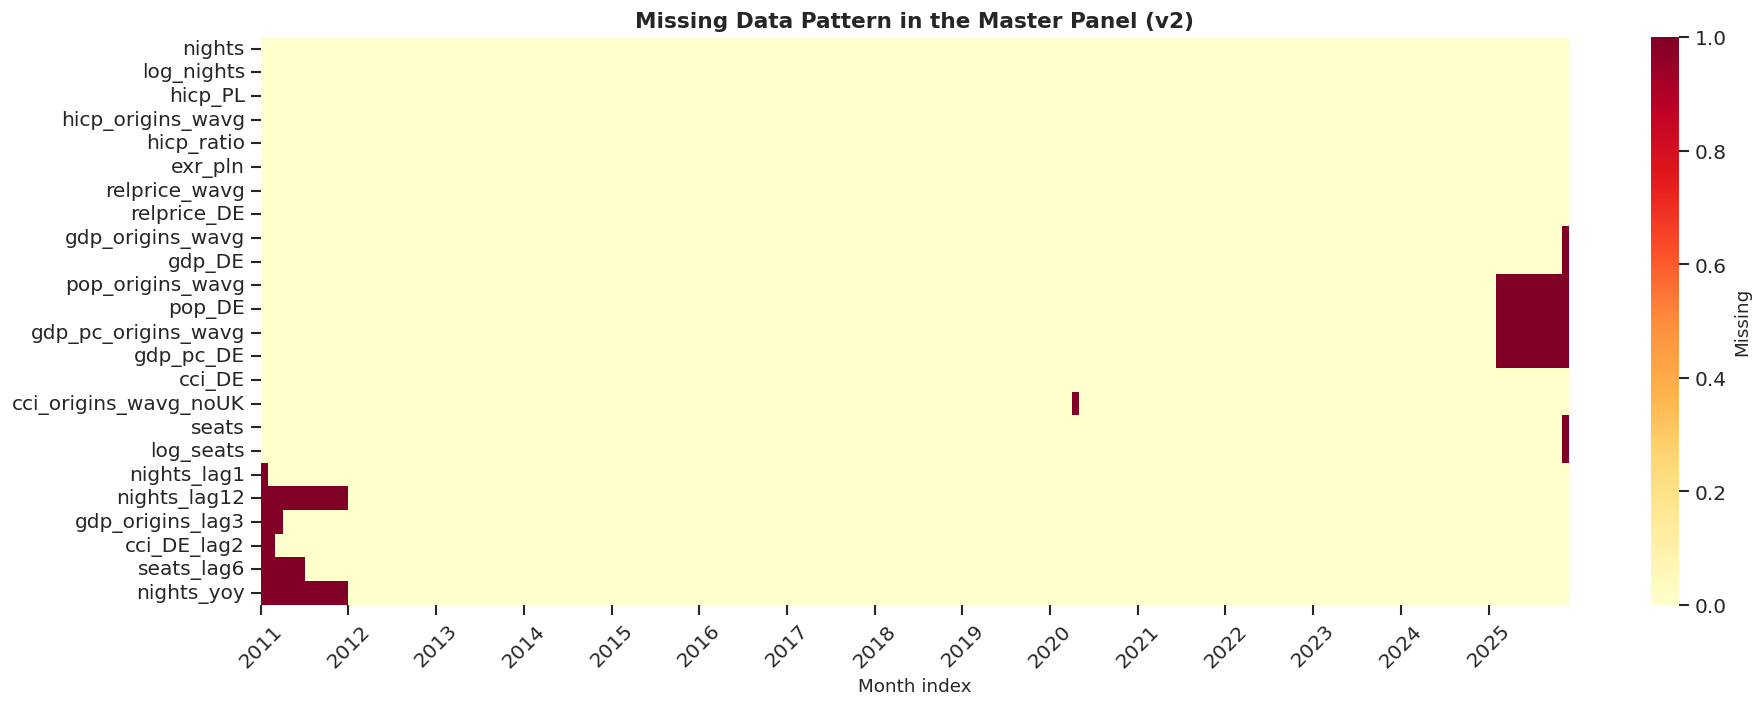

In [20]:
# Missing data heatmap:
fig, ax = plt.subplots(figsize=(16, 6))
non_dummy = [c for c in panel.columns
             if not c.startswith('month_')
             and c not in ['trend', 'covid_strong', 'covid_post']]
missing_matrix = panel[non_dummy].isna().astype(int)
sns.heatmap(missing_matrix.T, cmap='YlOrRd', cbar_kws={'label': 'Missing'},
            ax=ax, yticklabels=True)
ax.set_title('Missing Data Pattern in the Master Panel (v2)', fontweight='bold')
ax.set_xlabel('Month index')
xtick_positions = list(range(0, len(panel), 12))
ax.set_xticks(xtick_positions)
ax.set_xticklabels([panel.index[i].strftime('%Y') for i in xtick_positions],
                   rotation=45)
plt.tight_layout()
savefig('01_missing_data_heatmap.png')
plt.show()

## 7. Export Master Panel

In [21]:
output_path = os.path.join(DATA_PROCESSED, 'master_panel_monthly.csv')
panel.to_csv(output_path)
file_size = os.path.getsize(output_path) / 1024
print(f'Exported: {output_path}')
print(f'Size: {file_size:.1f} KB')
print(f'Shape: {panel.shape[0]} rows x {panel.shape[1]} columns')
print(f'\nColumn list ({len(panel.columns)}):')
for i, c in enumerate(panel.columns):
    print(f'  {i+1:2d}. {c}')

Exported: ..\data\processed\master_panel_monthly.csv
Size: 67.6 KB
Shape: 179 rows x 39 columns

Column list (39):
   1. nights
   2. log_nights
   3. hicp_PL
   4. hicp_origins_wavg
   5. hicp_ratio
   6. exr_pln
   7. relprice_wavg
   8. relprice_DE
   9. gdp_origins_wavg
  10. gdp_DE
  11. pop_origins_wavg
  12. pop_DE
  13. gdp_pc_origins_wavg
  14. gdp_pc_DE
  15. cci_DE
  16. cci_origins_wavg_noUK
  17. seats
  18. log_seats
  19. nights_lag1
  20. nights_lag12
  21. gdp_origins_lag3
  22. cci_DE_lag2
  23. seats_lag6
  24. covid_strong
  25. covid_post
  26. month_01
  27. month_02
  28. month_03
  29. month_04
  30. month_05
  31. month_06
  32. month_07
  33. month_08
  34. month_09
  35. month_10
  36. month_11
  37. month_12
  38. trend
  39. nights_yoy


### 7.1 Column Reference for Downstream Notebooks

| Column | Description | Source | Frequency |
|--------|-------------|--------|-----------|
| `nights` | Foreign overnight stays in Poland | `tour_occ_nim` (Eurostat) | Monthly |
| `log_nights` | Log-transformed target | Derived | Monthly |
| `hicp_PL` | HICP index, Poland (base 2015=100) | `prc_hicp_midx` (Eurostat) | Monthly |
| `hicp_origins_wavg` | HICP weighted avg of 9 origin markets | Derived (passenger-share weighted) | Monthly |
| `hicp_ratio` | Relative price: HICP_PL / HICP_origins | Derived | Monthly |
| `exr_pln` | Exchange rate PLN per EUR | `ert_bil_eur_m` (Eurostat / ECB) | Monthly |
| `relprice_wavg` | Relative tourism price (Song et al. 2010), weighted avg | Derived | Monthly |
| `relprice_DE` | Relative tourism price, Germany only | Derived | Monthly |
| `gdp_origins_wavg` | Real GDP weighted avg, chain-linked volumes 2010 | `namq_10_gdp` (Eurostat) + ONS ABMI (UK) | Quarterly -> Monthly (cubic spline) |
| `gdp_DE` | Real GDP, Germany | `namq_10_gdp` | Quarterly -> Monthly |
| `gdp_pc_origins_wavg` | GDP per capita weighted avg (EUR/person) | Derived from GDP and population | Monthly |
| `gdp_pc_DE` | GDP per capita, Germany | Derived | Monthly |
| `pop_origins_wavg` | Population weighted avg across origins | `demo_pjan` (Eurostat) + ONS UKPOP (UK) | Annual -> Monthly (cubic spline) |
| `pop_DE` | Population, Germany | `demo_pjan` | Annual -> Monthly |
| `cci_DE` | Consumer Confidence Indicator, Germany | `ei_bsco_m` (Eurostat / DG ECFIN) | Monthly |
| `cci_origins_wavg_noUK` | CCI weighted avg excluding UK (reference only) | Derived | Monthly |
| `seats` | Airline seats available, all Polish airports | `avia_tf_aca` (Eurostat) | Monthly |
| `log_seats` | Log-transformed seats | Derived | Monthly |
| `nights_lag1` | Target autoregressive lag t-1 | Derived | Monthly |
| `nights_lag12` | Target seasonal lag t-12 | Derived | Monthly |
| `gdp_origins_lag3` | GDP origins (weighted avg) at lag 3 | Derived | Monthly |
| `cci_DE_lag2` | German CCI at lag 2 | Derived | Monthly |
| `seats_lag6` | Airline seats at lag 6 (IATA planning horizon) | Derived | Monthly |
| `covid_strong` | Dummy: hard pandemic period 2020-2021 | Control | Monthly |
| `covid_post` | Dummy: post-pandemic level shift 2022-2025 | Control | Monthly |
| `month_01` ... `month_12` | Monthly seasonal dummies (12 columns) | Control | Monthly |
| `trend` | Linear trend index (0, 1, 2, ...) | Control | Monthly |
| `nights_yoy` | Year-over-year growth rate of target | Reference | Monthly |

**UK-specific notes:**
- UK HICP has been chain-linked with ONS series D7BT after 2020-11 (splice factor absorbs base year differences).
- UK GDP has been chain-linked with ONS series ABMI after Q3 2020 (splice factor absorbs GBP->EUR conversion and CLV2022->CLV2010 rebasing).
- UK population comes from ONS UKPOP, replacing the Eurostat gaps after 2020.
- UK CCI is excluded entirely; no cross-source mixing for the sentiment indicator.

**Multicollinearity warning (VIF on first differences):** GDP, GDP per capita, and population satisfy the identity `GDP = GDP_pc x pop`, so including all three simultaneously in a single model creates exact collinearity. Downstream notebooks should include at most two of the three, with preference for `gdp_pc_origins_wavg + pop_origins_wavg` when the tutor-recommended interpretation (individual wealth x market size) is appropriate.

---

*End of Notebook 04 (v2) -- Next: re-run Notebook 05 with the updated panel.*